# Pit Shell and Blast Master Prototype

This notebook creates an initial open pit shell polygon and an internal toe-line polygon for the bench below. It is intended as a clean starting point for building a later blast master workflow.

The first version focuses on:

- defining the pit strike length in the east-west direction;
- defining the pit width in the north-south direction;
- generating a near-elliptical pit shell with controlled irregularity so the outline is not perfectly smooth;
- generating an internal toe line based on bench height and wall angle;
- plotting both polygons in plan view for visual inspection.

Later stages can add benches, ramps, trim blasts, regular blast pattern generation, blast IDs, sequencing and export tables.

## 1. Import required libraries

This cell imports the Python libraries required for geometry generation, data handling, and visualisation.

The workflow uses NumPy and Pandas for numerical and tabular processing, Matplotlib for plotting, and Shapely for polygon, line, buffer, and intersection operations.

In [25]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.geometry import LineString
from shapely.ops import substring
from IPython.display import display
import ipywidgets as widgets


## 2. User-defined inputs

This cell contains all user-defined parameters for the pit shell, bench geometry, trim buffer, ramp, slot, and production blast design.

In [26]:
# ============================================================
# USER INPUTS
# ============================================================

# --- Pit shell footprint ---
strike_length_m = 550.0
pit_width_m = 280.0
centre_x = 363600.0
centre_y = 6591800.0

# --- Shell realism ---
n_boundary_points = 180
irregularity_pct = 0.01
smoothing_window = 11
random_seed = 42

# --- Bench / toe-line geometry ---
crest_rl = 200.0
bench_height_m = 10.0
wall_angle_deg = 80.0

# --- Trim buffer ---
trim_buffer_width_m = 30.0

# --- Ramp design ---
ramp_side = "south"
ramp_gradient_ratio = 10.0
ramp_width_m = trim_buffer_width_m

# --- Slot pattern ---
slot_length_m = 60.0
slot_width_m = 45.0
slot_development_direction = "clockwise"  # "clockwise" or "counterclockwise"

# --- Production blast design ---
first_production_blast_depth_m = 80.0

# ============================================================
# DERIVED VALUES
# ============================================================

floor_rl = crest_rl - bench_height_m
wall_angle_rad = math.radians(wall_angle_deg)
toe_offset_m = bench_height_m / math.tan(wall_angle_rad)

ramp_length_m = bench_height_m * ramp_gradient_ratio

print(f"Floor RL: {floor_rl:.2f} m")
print(f"Toe-line inward offset: {toe_offset_m:.2f} m")
print(f"Trim buffer width: {trim_buffer_width_m:.1f} m")
print(f"Ramp gradient: 1:{ramp_gradient_ratio:.1f}")
print(f"Ramp width: {ramp_width_m:.1f} m")
print(f"Required ramp length: {ramp_length_m:.1f} m")
print(f"Slot length: {slot_length_m:.1f} m")
print(f"Slot width: {slot_width_m:.1f} m")
print(f"First production blast depth: {first_production_blast_depth_m:.1f} m")

Floor RL: 190.00 m
Toe-line inward offset: 1.76 m
Trim buffer width: 30.0 m
Ramp gradient: 1:10.0
Ramp width: 30.0 m
Required ramp length: 100.0 m
Slot length: 60.0 m
Slot width: 45.0 m
First production blast depth: 80.0 m


## 3. Define reusable helper functions

This cell defines the reusable functions used throughout the notebook.

These functions handle pit shell generation, polygon cleaning, inward offsets, cyclic smoothing, circular boundary extraction, shape-quality checks, and common plotting behaviour.

In [27]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def smooth_cyclic(values: np.ndarray, window: int) -> np.ndarray:
    """Smooth a cyclic 1D array using a centred moving average."""
    window = int(max(1, window))

    if window % 2 == 0:
        window += 1

    if window <= 1:
        return values

    pad = window // 2
    padded = np.r_[values[-pad:], values, values[:pad]]
    kernel = np.ones(window) / window

    return np.convolve(padded, kernel, mode="valid")


def create_irregular_pit_shell(
    strike_length: float,
    pit_width: float,
    centre: tuple[float, float],
    n_points: int,
    irregularity: float,
    smoothing_window: int,
    seed: int,
) -> np.ndarray:
    """Create an irregular east-west elongated pit shell polygon."""
    rng = np.random.default_rng(seed)
    theta = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

    noise = rng.normal(0, 1, n_points)
    smooth_noise = smooth_cyclic(noise, smoothing_window)
    smooth_noise = smooth_noise / max(np.max(np.abs(smooth_noise)), 1e-9)

    radial_multiplier = 1.0 + irregularity * smooth_noise

    a = strike_length / 2.0
    b = pit_width / 2.0
    cx, cy = centre

    x = cx + a * np.cos(theta) * radial_multiplier
    y = cy + b * np.sin(theta) * radial_multiplier

    return np.column_stack([x, y])


def clean_polygon(poly: Polygon) -> Polygon:
    """Repair minor invalid polygon geometry."""
    if not poly.is_valid:
        poly = poly.buffer(0)
    return poly


def inward_offset_polygon(coords: np.ndarray, offset_distance: float) -> np.ndarray:
    """Offset a polygon inward using Shapely negative buffer."""
    if offset_distance <= 0:
        return coords.copy()

    poly = clean_polygon(Polygon(coords))
    inner = poly.buffer(-offset_distance, join_style=2)

    if inner.is_empty:
        raise ValueError("Inward offset collapsed the polygon.")

    if inner.geom_type == "MultiPolygon":
        inner = max(inner.geoms, key=lambda g: g.area)

    return np.array(inner.exterior.coords[:-1])


def polygon_area(coords: np.ndarray) -> float:
    """Calculate polygon area using the shoelace formula."""
    x = coords[:, 0]
    y = coords[:, 1]

    return 0.5 * abs(
        np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
    )


def coords_to_dataframe(coords: np.ndarray, line_name: str, rl: float) -> pd.DataFrame:
    """Convert polygon coordinates to a tidy dataframe."""
    df = pd.DataFrame(coords, columns=["x", "y"])
    df.insert(0, "point_id", np.arange(1, len(df) + 1))
    df.insert(1, "line_name", line_name)
    df["rl"] = rl

    return df


def circular_substring(line: LineString, start_dist: float, length: float) -> LineString:
    """Extract a section from a closed LineString, allowing wrap-around."""
    total_length = line.length
    start_dist = start_dist % total_length
    end_dist = start_dist + length

    if end_dist <= total_length:
        return substring(line, start_dist, end_dist)

    first_part = substring(line, start_dist, total_length)
    second_part = substring(line, 0, end_dist - total_length)

    coords = list(first_part.coords) + list(second_part.coords)
    return LineString(coords)


def compactness_ratio(geom) -> float:
    """Simple shape-quality check based on minimum rotated rectangle."""
    if geom.is_empty or geom.area <= 0:
        return 0.0

    min_rect = geom.minimum_rotated_rectangle

    if min_rect.area <= 0:
        return 0.0

    return geom.area / min_rect.area


def plot_polygon(
    ax,
    geom,
    facecolor="none",
    edgecolor="black",
    alpha=1.0,
    linewidth=2,
    label=None,
):
    """Plot a Shapely Polygon or MultiPolygon."""
    if geom.is_empty:
        return

    if geom.geom_type == "Polygon":
        geoms = [geom]
    elif geom.geom_type == "MultiPolygon":
        geoms = list(geom.geoms)
    else:
        return

    for poly in geoms:
        x, y = poly.exterior.xy

        ax.fill(
            x,
            y,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
            linewidth=linewidth,
            label=label,
        )

        label = None

        for interior in poly.interiors:
            ix, iy = interior.xy
            ax.fill(ix, iy, facecolor="white", edgecolor=edgecolor, linewidth=1)


def setup_plan_axis(ax, title: str):
    """Apply common formatting to plan-view plots."""
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Easting / X (m)")
    ax.set_ylabel("Northing / Y (m)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
    
def get_reference_boundary_point(boundary: LineString, side: str) -> tuple[float, float]:
    """Return the boundary point used to place the ramp."""
    coords = list(boundary.coords)

    if side.lower() == "south":
        idx = min(range(len(coords)), key=lambda i: coords[i][1])
    elif side.lower() == "north":
        idx = max(range(len(coords)), key=lambda i: coords[i][1])
    elif side.lower() == "east":
        idx = max(range(len(coords)), key=lambda i: coords[i][0])
    elif side.lower() == "west":
        idx = min(range(len(coords)), key=lambda i: coords[i][0])
    else:
        raise ValueError("side must be one of: south, north, east, west.")

    return coords[idx]


def make_boundary_rectangle(
    segment: LineString,
    reference_polygon: Polygon,
    offset_inward_m: float,
    depth_m: float,
) -> Polygon:
    """
    Create a straight-sided rectangular polygon from a boundary segment.

    The rectangle uses the segment start and end points as its width direction.
    It is then projected inward from the reference polygon boundary.
    """
    coords = list(segment.coords)

    if len(coords) < 2:
        raise ValueError("Segment must contain at least two coordinates.")

    p0 = np.array(coords[0], dtype=float)
    p1 = np.array(coords[-1], dtype=float)

    tangent = p1 - p0
    tangent_length = np.linalg.norm(tangent)

    if tangent_length <= 1e-9:
        raise ValueError("Segment has negligible length.")

    tangent = tangent / tangent_length

    # Two possible normals
    n1 = np.array([-tangent[1], tangent[0]])
    n2 = np.array([tangent[1], -tangent[0]])

    midpoint = (p0 + p1) / 2.0
    centroid = np.array([reference_polygon.centroid.x, reference_polygon.centroid.y])

    # Select the normal that points inward towards the polygon centroid
    inward = n1 if np.dot(centroid - midpoint, n1) > np.dot(centroid - midpoint, n2) else n2

    outer_left = p0 + inward * offset_inward_m
    outer_right = p1 + inward * offset_inward_m
    inner_right = p1 + inward * (offset_inward_m + depth_m)
    inner_left = p0 + inward * (offset_inward_m + depth_m)

    return Polygon([outer_left, outer_right, inner_right, inner_left])


def geometry_area_ratio(candidate: Polygon, clipped) -> float:
    """Return clipped area as a proportion of original candidate area."""
    if candidate.is_empty or candidate.area <= 0:
        return 0.0

    if clipped.is_empty:
        return 0.0

    return clipped.area / candidate.area

## 4. Build the pit shell, toe line, trim buffer, and final ramp

This cell generates the initial pit shell footprint and offsets it inward to represent the toe line of the bench below.

It then creates the internal trim buffer zone and places the final ramp along the selected side of the pit shell. The outputs from this step provide the base geometry for the blast pattern design.

In [28]:
# ============================================================
# BUILD PIT SHELL, TOE LINE, TRIM BUFFER AND FINAL RAMP
# ============================================================

pit_shell_xy = create_irregular_pit_shell(
    strike_length=strike_length_m,
    pit_width=pit_width_m,
    centre=(centre_x, centre_y),
    n_points=n_boundary_points,
    irregularity=irregularity_pct,
    smoothing_window=smoothing_window,
    seed=random_seed,
)

toe_line_xy = inward_offset_polygon(pit_shell_xy, toe_offset_m)

pit_shell_polygon = clean_polygon(Polygon(pit_shell_xy))
toe_line_polygon = clean_polygon(Polygon(toe_line_xy))

# Blast design starts from the toe line, not the crest.
design_boundary_polygon = toe_line_polygon
design_boundary = LineString(design_boundary_polygon.exterior.coords)

inner_trim_edge_polygon = design_boundary_polygon.buffer(-trim_buffer_width_m)

if inner_trim_edge_polygon.is_empty:
    raise ValueError(
        "Trim buffer width is too large. The inward buffer collapsed the toe-line polygon."
    )

trim_buffer_zone = design_boundary_polygon.difference(inner_trim_edge_polygon)

# --- Ramp placement ---
ramp_point = get_reference_boundary_point(design_boundary, ramp_side)
ramp_centre_distance = design_boundary.project(Point(ramp_point))

ramp_start_distance = max(0, ramp_centre_distance - ramp_length_m / 2)
ramp_end_distance = min(design_boundary.length, ramp_centre_distance + ramp_length_m / 2)

ramp_outer_segment = substring(
    design_boundary,
    ramp_start_distance,
    ramp_end_distance,
)

ramp_corridor = ramp_outer_segment.buffer(
    ramp_width_m * 1.5,
    cap_style=2,
    join_style=2,
)

final_ramp_polygon = trim_buffer_zone.intersection(ramp_corridor)

if final_ramp_polygon.is_empty:
    raise ValueError(
        "Final ramp polygon is empty. Try reducing ramp length, trim width, or changing ramp side."
    )

trim_blast_zone_excluding_ramp = trim_buffer_zone.difference(final_ramp_polygon)

summary = pd.DataFrame([
    {
        "geometry": "pit_shell_crest",
        "rl": crest_rl,
        "area_m2": pit_shell_polygon.area,
    },
    {
        "geometry": "toe_line_floor",
        "rl": floor_rl,
        "area_m2": toe_line_polygon.area,
    },
    {
        "geometry": "toe_based_trim_buffer",
        "rl": floor_rl,
        "area_m2": trim_buffer_zone.area,
    },
    {
        "geometry": "final_ramp",
        "rl": floor_rl,
        "area_m2": final_ramp_polygon.area,
    },
])

summary

,geometry,rl,area_m2
0,pit_shell_crest,200.0,120687.552343
1,toe_line_floor,190.0,118339.075267
2,toe_based_trim_buffer,190.0,36953.673392
3,final_ramp,190.0,2935.249419


## 5. Create the slot and first production blast

This cell creates the initial slot pattern from the end of the final ramp.

The slot follows the pit perimeter for the nominated slot length and sits inside the trim buffer. The first production blast is then created behind the slot, firing back into the void created by the slot blast.

In [29]:
# ============================================================
# BUILD SLOT AND FIRST PRODUCTION BLAST
# ============================================================

# --- Slot starts at one end of the ramp ---
if slot_development_direction.lower() == "clockwise":
    slot_start_distance = ramp_end_distance
    slot_signed_length = slot_length_m

elif slot_development_direction.lower() == "counterclockwise":
    slot_start_distance = ramp_start_distance
    slot_signed_length = -slot_length_m

else:
    raise ValueError("slot_development_direction must be 'clockwise' or 'counterclockwise'.")


if slot_signed_length >= 0:
    slot_outer_segment = circular_substring(
        design_boundary,
        slot_start_distance,
        slot_signed_length,
    )
else:
    reversed_boundary = LineString(list(design_boundary.coords)[::-1])
    reversed_start = reversed_boundary.project(
        design_boundary.interpolate(slot_start_distance)
    )

    slot_outer_segment = circular_substring(
        reversed_boundary,
        reversed_start,
        abs(slot_signed_length),
    )


# --- Slot sits inside toe-based trim buffer ---
slot_corridor = slot_outer_segment.buffer(
    slot_width_m,
    cap_style=2,
    join_style=2,
)

slot_pattern_polygon = slot_corridor.intersection(trim_blast_zone_excluding_ramp)

if slot_pattern_polygon.is_empty:
    raise ValueError(
        "Slot pattern polygon is empty. Try increasing slot width or changing ramp/slot direction."
    )

trim_blast_zone_remaining = trim_blast_zone_excluding_ramp.difference(slot_pattern_polygon)


# --- First production blast behind the slot ---
first_production_candidate = make_boundary_rectangle(
    segment=slot_outer_segment,
    reference_polygon=design_boundary_polygon,
    offset_inward_m=trim_buffer_width_m,
    depth_m=first_production_blast_depth_m,
)

first_production_blast_polygon = first_production_candidate.intersection(
    design_boundary_polygon.difference(trim_buffer_zone)
)

if first_production_blast_polygon.is_empty:
    raise ValueError(
        "First production blast polygon is empty. Try increasing first production blast depth."
    )

print("Ramp, slot and first production blast generated successfully.")
print(f"Ramp area: {final_ramp_polygon.area:,.0f} m²")
print(f"Slot area: {slot_pattern_polygon.area:,.0f} m²")
print(f"First production blast area: {first_production_blast_polygon.area:,.0f} m²")

Ramp, slot and first production blast generated successfully.
Ramp area: 2,935 m²
Slot area: 1,758 m²
First production blast area: 4,794 m²


## 6. Visualise the full blast development sequence

This cell plots the complete blast development layout.

The plot shows the pit shell, toe line, trim buffer, final ramp, slot and first production blast.

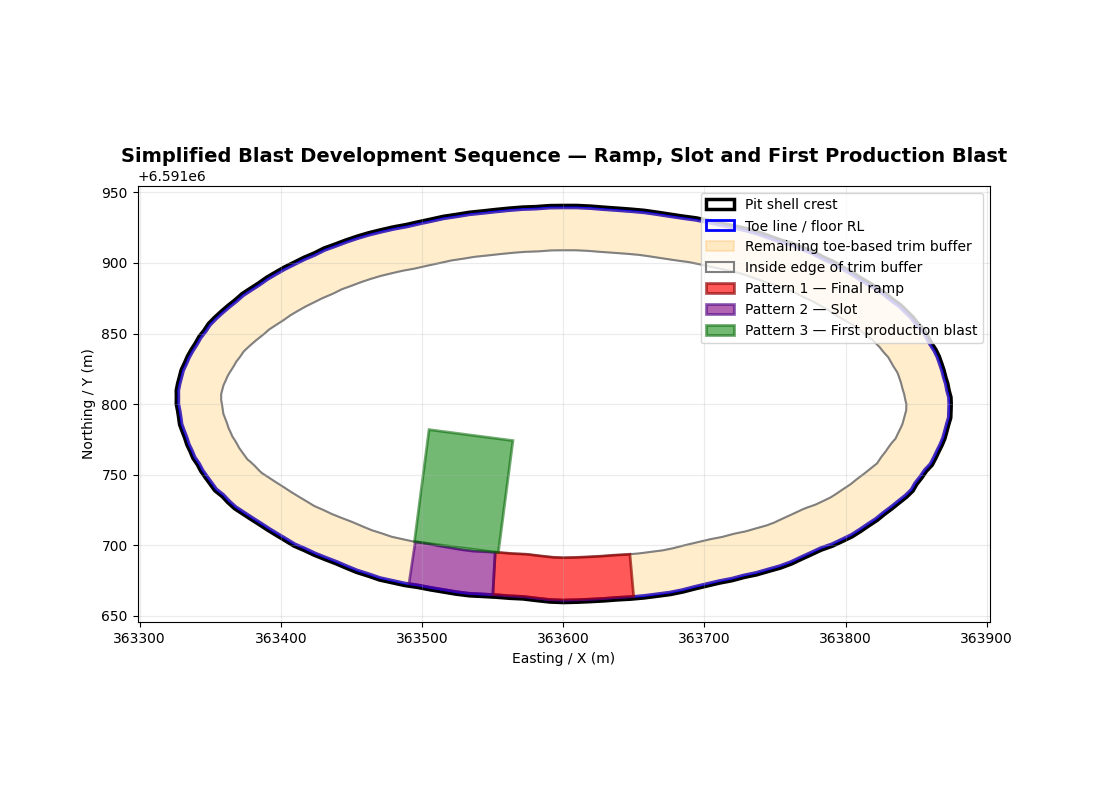

In [30]:
# ============================================================
# VISUALISE RAMP, SLOT AND FIRST PRODUCTION BLAST
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))

plot_polygon(
    ax,
    pit_shell_polygon,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    label="Pit shell crest",
)

plot_polygon(
    ax,
    toe_line_polygon,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="Toe line / floor RL",
)

plot_polygon(
    ax,
    trim_blast_zone_remaining,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.20,
    linewidth=1.2,
    label="Remaining toe-based trim buffer",
)

plot_polygon(
    ax,
    inner_trim_edge_polygon,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.5,
    label="Inside edge of trim buffer",
)

plot_polygon(
    ax,
    final_ramp_polygon,
    facecolor="red",
    edgecolor="darkred",
    alpha=0.65,
    linewidth=2,
    label="Pattern 1 — Final ramp",
)

plot_polygon(
    ax,
    slot_pattern_polygon,
    facecolor="purple",
    edgecolor="indigo",
    alpha=0.60,
    linewidth=2,
    label="Pattern 2 — Slot",
)

plot_polygon(
    ax,
    first_production_blast_polygon,
    facecolor="green",
    edgecolor="darkgreen",
    alpha=0.55,
    linewidth=2,
    label="Pattern 3 — First production blast",
)

setup_plan_axis(
    ax,
    "Simplified Blast Development Sequence — Ramp, Slot and First Production Blast",
)

plt.show()

## 7. Prepare interactive production blast drawing

This cell prepares the data structures used to store manually drawn production blast polygons.

The user will define each production blast by clicking points on the plan-view canvas. Once the required points have been selected, the polygon can be closed and saved as a new blast pattern.

In [31]:
# ============================================================
# INITIALISE INTERACTIVE PRODUCTION BLAST STORAGE
# ============================================================

manual_production_blasts = []
current_polygon_points = []

blast_counter_start = 4  # Pattern 1 = ramp, 2 = slot, 3 = first production blast

print("Manual production blast storage initialised.")
print("Next production blast will be Pattern 4.")

Manual production blast storage initialised.
Next production blast will be Pattern 4.


## 8. Interactive production blast drawing canvas

This cell opens an interactive plan-view canvas.

Click on the canvas to define the corners of a production blast. Use **Save Blast** to close and store the polygon, then continue drawing the next blast. Use **Finish** when all production blasts have been created.

In [32]:
%matplotlib widget

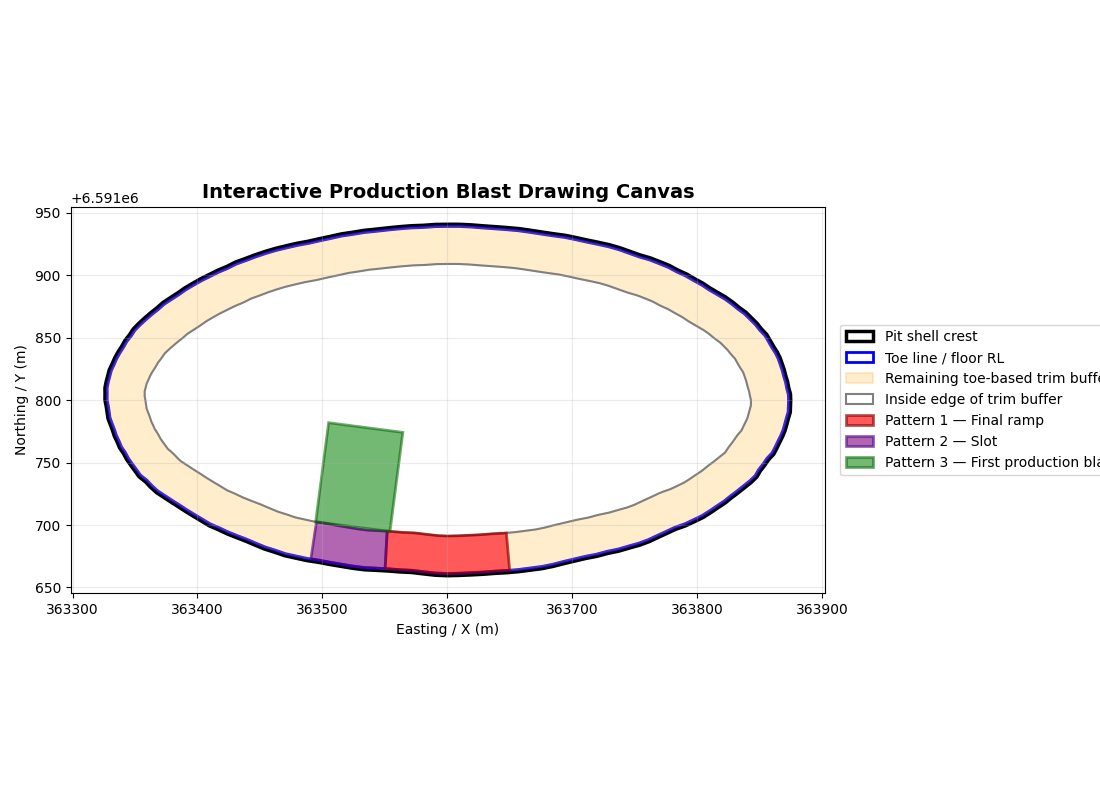

In [33]:
# ============================================================
# INTERACTIVE PRODUCTION BLAST DRAWING CANVAS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))

fig.canvas.toolbar_visible = True
fig.canvas.header_visible = False
fig.canvas.footer_visible = True
fig.canvas.resizable = True

# ------------------------------------------------------------
# Base geometry
# ------------------------------------------------------------

plot_polygon(
    ax,
    pit_shell_polygon,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    label="Pit shell crest",
)

plot_polygon(
    ax,
    toe_line_polygon,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="Toe line / floor RL",
)

plot_polygon(
    ax,
    trim_blast_zone_remaining,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.20,
    linewidth=1.2,
    label="Remaining toe-based trim buffer",
)

plot_polygon(
    ax,
    inner_trim_edge_polygon,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.5,
    label="Inside edge of trim buffer",
)

plot_polygon(
    ax,
    final_ramp_polygon,
    facecolor="red",
    edgecolor="darkred",
    alpha=0.65,
    linewidth=2,
    label="Pattern 1 — Final ramp",
)

plot_polygon(
    ax,
    slot_pattern_polygon,
    facecolor="purple",
    edgecolor="indigo",
    alpha=0.60,
    linewidth=2,
    label="Pattern 2 — Slot",
)

plot_polygon(
    ax,
    first_production_blast_polygon,
    facecolor="green",
    edgecolor="darkgreen",
    alpha=0.55,
    linewidth=2,
    label="Pattern 3 — First production blast",
)

ax.set_aspect("equal", adjustable="box")
ax.set_title("Interactive Production Blast Drawing Canvas", fontsize=14, fontweight="bold")
ax.set_xlabel("Easting / X (m)")
ax.set_ylabel("Northing / Y (m)")
ax.grid(True, alpha=0.25)

# Move legend outside the drawing area
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)

plt.tight_layout()

# ------------------------------------------------------------
# Interactive drawing state
# ------------------------------------------------------------

current_line, = ax.plot([], [], marker="o", linestyle="-", linewidth=2, label="Current polygon")
saved_artists = []

status = widgets.HTML(
    value="<b>Status:</b> Click points to begin drawing Pattern 4."
)

save_button = widgets.Button(
    description="Save Blast",
    button_style="success",
    tooltip="Close and save the current polygon",
)

undo_button = widgets.Button(
    description="Undo Point",
    button_style="warning",
    tooltip="Remove the most recent point",
)

clear_button = widgets.Button(
    description="Clear Current",
    button_style="danger",
    tooltip="Clear the current unsaved polygon",
)

finish_button = widgets.Button(
    description="Finish",
    button_style="primary",
    tooltip="Finish drawing production blasts",
)


def refresh_current_line():
    """Refresh the temporary polygon line on the canvas."""
    if len(current_polygon_points) == 0:
        current_line.set_data([], [])
    else:
        xs = [p[0] for p in current_polygon_points]
        ys = [p[1] for p in current_polygon_points]
        current_line.set_data(xs, ys)

    fig.canvas.draw_idle()


def next_pattern_id():
    """Return the next manual production blast pattern ID."""
    return blast_counter_start + len(manual_production_blasts)


def on_click(event):
    """Add clicked point to current polygon."""
    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    current_polygon_points.append((event.xdata, event.ydata))

    status.value = (
        f"<b>Status:</b> Drawing Pattern {next_pattern_id()} — "
        f"{len(current_polygon_points)} point(s) selected."
    )

    refresh_current_line()


def on_save_clicked(_):
    """Close and save the current polygon as a production blast."""
    if len(current_polygon_points) < 3:
        status.value = "<b>Status:</b> Select at least 3 points before saving a blast."
        return

    candidate_polygon = Polygon(current_polygon_points)

    if not candidate_polygon.is_valid:
        candidate_polygon = candidate_polygon.buffer(0)

    if candidate_polygon.is_empty or candidate_polygon.area <= 0:
        status.value = "<b>Status:</b> Invalid polygon. Clear current points and redraw."
        return

    # Keep the manually drawn blast inside the available toe-line production area.
    production_domain = design_boundary_polygon.difference(trim_buffer_zone)

    saved_polygon = candidate_polygon.intersection(production_domain)

    # Prevent overlap with previous fixed patterns and previous manual blasts.
    already_assigned = first_production_blast_polygon

    for blast in manual_production_blasts:
        already_assigned = already_assigned.union(blast["polygon"])

    saved_polygon = saved_polygon.difference(already_assigned)

    if saved_polygon.is_empty or saved_polygon.area <= 0:
        status.value = (
            "<b>Status:</b> Saved polygon has no valid remaining area after clipping. "
            "Try drawing in an unassigned production area."
        )
        return

    if saved_polygon.geom_type == "MultiPolygon":
        saved_polygon = max(saved_polygon.geoms, key=lambda g: g.area)

    pattern_id = next_pattern_id()

    manual_production_blasts.append({
        "pattern_id": pattern_id,
        "pattern_type": "Production",
        "polygon": saved_polygon,
        "area_m2": saved_polygon.area,
    })

    x, y = saved_polygon.exterior.xy

    artist = ax.fill(
        x,
        y,
        facecolor="cyan",
        edgecolor="blue",
        alpha=0.45,
        linewidth=1.5,
        label=f"Pattern {pattern_id} — Manual production",
    )

    saved_artists.extend(artist)

    current_polygon_points.clear()
    refresh_current_line()

    status.value = (
        f"<b>Status:</b> Pattern {pattern_id} saved. "
        f"Area = {saved_polygon.area:,.0f} m². "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

    fig.canvas.draw_idle()


def on_undo_clicked(_):
    """Remove the most recent point."""
    if current_polygon_points:
        current_polygon_points.pop()

    status.value = (
        f"<b>Status:</b> Drawing Pattern {next_pattern_id()} — "
        f"{len(current_polygon_points)} point(s) selected."
    )

    refresh_current_line()


def on_clear_clicked(_):
    """Clear the current unsaved polygon."""
    current_polygon_points.clear()

    status.value = (
        f"<b>Status:</b> Current polygon cleared. "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

    refresh_current_line()


def on_finish_clicked(_):
    """Disconnect the click handler and finish drawing."""
    fig.canvas.mpl_disconnect(click_connection_id)

    current_polygon_points.clear()
    refresh_current_line()

    status.value = (
        f"<b>Status:</b> Finished. "
        f"{len(manual_production_blasts)} manual production blast(s) saved."
    )


click_connection_id = fig.canvas.mpl_connect("button_press_event", on_click)

controls = widgets.HBox([
    save_button,
    undo_button,
    clear_button,
    finish_button,
])

save_button.on_click(on_save_clicked)
undo_button.on_click(on_undo_clicked)
clear_button.on_click(on_clear_clicked)
finish_button.on_click(on_finish_clicked)

display(widgets.VBox([controls, status]))

plt.subplots_adjust(right=0.75)

plt.show()

## 9. Convert manually drawn blasts to a summary table

This cell converts the manually drawn production blast polygons into a summary dataframe.

The resulting table can be used for checking blast IDs, pattern types, areas, and later export into a blast master dataset.

In [34]:
# ============================================================
# CREATE MANUAL PRODUCTION BLAST SUMMARY
# ============================================================

manual_blast_summary = pd.DataFrame([
    {
        "pattern_id": blast["pattern_id"],
        "pattern_type": blast["pattern_type"],
        "area_m2": blast["area_m2"],
    }
    for blast in manual_production_blasts
])

manual_blast_summary

""


## 10. Final review plot with manually drawn production blasts

This cell creates a static review plot showing the ramp, slot, first production blast, and all manually drawn production blasts.

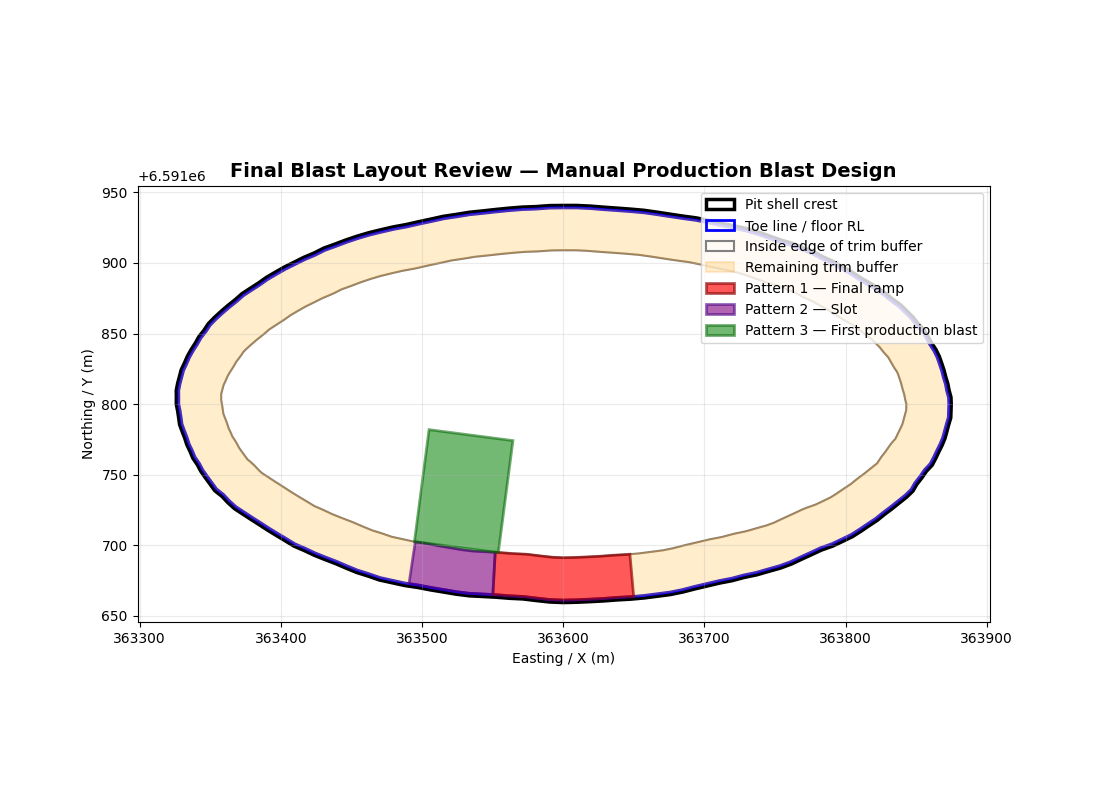

In [35]:
# ============================================================
# FINAL REVIEW PLOT WITH MANUAL PRODUCTION BLASTS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))

plot_polygon(ax, pit_shell_polygon, facecolor="none", edgecolor="black", linewidth=2.5, label="Pit shell crest")
plot_polygon(ax, toe_line_polygon, facecolor="none", edgecolor="blue", linewidth=2, label="Toe line / floor RL")
plot_polygon(ax, inner_trim_edge_polygon, facecolor="none", edgecolor="grey", linewidth=1.5, label="Inside edge of trim buffer")
plot_polygon(ax, trim_blast_zone_remaining, facecolor="orange", edgecolor="darkorange", alpha=0.20, linewidth=1.2, label="Remaining trim buffer")

plot_polygon(ax, final_ramp_polygon, facecolor="red", edgecolor="darkred", alpha=0.65, linewidth=2, label="Pattern 1 — Final ramp")
plot_polygon(ax, slot_pattern_polygon, facecolor="purple", edgecolor="indigo", alpha=0.60, linewidth=2, label="Pattern 2 — Slot")
plot_polygon(ax, first_production_blast_polygon, facecolor="green", edgecolor="darkgreen", alpha=0.55, linewidth=2, label="Pattern 3 — First production blast")

for blast in manual_production_blasts:
    plot_polygon(
        ax,
        blast["polygon"],
        facecolor="cyan",
        edgecolor="blue",
        alpha=0.45,
        linewidth=1.5,
        label=f"Pattern {blast['pattern_id']} — Manual production",
    )

setup_plan_axis(
    ax,
    "Final Blast Layout Review — Manual Production Blast Design",
)

plt.show()